
# Business Objective – Home Credit Application Dataset

## Business Objective

Home Credit provides loans to customers who may have limited or no traditional credit history. The main business objective is to analyze loan applicant information and identify meaningful groups of applicants with similar financial, demographic, employment, and credit-related characteristics.

Using clustering techniques, the goal is to discover hidden customer segments without using a predefined target variable.

## Clustering Objectives

1. **Applicant Segmentation**
   - Group loan applicants based on similar financial and demographic characteristics.
   - Identify distinct types of credit applicants.

2. **Income-Based Segmentation**
   - Group applicants based on total income, loan amount, annuity amount, and other financial attributes.
   - Understand differences between low-, medium-, and high-income applicant groups.

3. **Credit Profile Segmentation**
   - Identify applicants with similar credit requirements.
   - Analyze relationships between requested credit amount, income, annuity, and goods price.

4. **Employment Profile Analysis**
   - Segment applicants based on employment-related characteristics.
   - Understand how employment duration, occupation, and income source differ across clusters.

5. **Demographic Segmentation**
   - Identify applicant groups based on age, family size, education, housing type, and other demographic characteristics.

6. **Financial Burden Analysis**
   - Identify groups with different levels of financial burden.
   - Analyze indicators such as:
     - Credit-to-Income Ratio
     - Annuity-to-Income Ratio
     - Credit-to-Goods-Price Ratio

7. **Potential Risk-Pattern Discovery**
   - Discover applicant groups whose characteristics may warrant different levels of credit review.
   - Clustering itself should not be treated as a loan-default prediction model because the test dataset does not contain the target/default label.

8. **Outlier Detection**
   - Identify applicants with unusual income, credit, annuity, employment, or demographic characteristics.
   - Detect applicants significantly different from the majority of customers.

9. **Business Decision Support**
   - Support customer segmentation and portfolio analysis.
   - Help design differentiated loan products and customer communication strategies.
   - Provide additional insights that can complement supervised credit-risk models.

## Machine Learning Objective

Apply unsupervised machine learning algorithms such as:

- K-Means Clustering
- Hierarchical / Agglomerative Clustering
- DBSCAN
- Mean Shift Clustering

Evaluate the quality of the generated clusters using:

- Elbow Method
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Cluster Visualization

## Expected Outcome

The expected outcome is to divide Home Credit loan applicants into meaningful customer segments based on similarities in their financial, demographic, employment, and credit characteristics.

These clusters can then be profiled to understand different types of loan applicants and support portfolio analysis, customer segmentation, credit review, and business strategy.

In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans,AgglomerativeClustering,MeanShift,DBSCAN
df=pd.read_excel(r"C:\clustering\data\application_test.xlsx")

In [6]:
df.columns

Index(['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       ...
       'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_YEAR.1',
       'Unnamed: 122'],
      dtype='str', length=123)

In [7]:
df=df[['AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','CNT_FAM_MEMBERS']]

In [8]:
df.shape

(48744, 8)

In [9]:
df.isna().sum()

AMT_CREDIT            0
AMT_ANNUITY          24
AMT_GOODS_PRICE       0
DAYS_BIRTH            0
DAYS_EMPLOYED         0
DAYS_REGISTRATION     0
DAYS_ID_PUBLISH       0
CNT_FAM_MEMBERS       0
dtype: int64

In [10]:
df.head

<bound method NDFrame.head of        AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  DAYS_BIRTH  DAYS_EMPLOYED  \
0        568800.0      20560.5         450000.0      -19241          -2329   
1        222768.0      17370.0         180000.0      -18064          -4469   
2        663264.0      69777.0         630000.0      -20038          -4458   
3       1575000.0      49018.5        1575000.0      -13976          -1866   
4        625500.0      32067.0         625500.0      -13040          -2191   
...           ...          ...              ...         ...            ...   
48739    412560.0      17473.5         270000.0      -19970          -5169   
48740    622413.0      31909.5         495000.0      -11186          -1149   
48741    315000.0      33205.5         315000.0      -15922          -3037   
48742    450000.0      25128.0         450000.0      -13968          -2731   
48743    312768.0      24709.5         270000.0      -13962           -633   

       DAYS_REGISTRATION  DAYS_ID

In [11]:
def fill_null_values(df):
    for column in df.columns:
        if df[column].isna().sum() > 0:
            if df[column].dtype in ['int64', 'float64']:
                df[column] = df[column].fillna(df[column].median())
    
    return df

df = fill_null_values(df)

df.isna().sum()

AMT_CREDIT           0
AMT_ANNUITY          0
AMT_GOODS_PRICE      0
DAYS_BIRTH           0
DAYS_EMPLOYED        0
DAYS_REGISTRATION    0
DAYS_ID_PUBLISH      0
CNT_FAM_MEMBERS      0
dtype: int64

In [10]:
df

,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,CNT_FAM_MEMBERS
0,568800.0,20560.5,450000.0,-19241,-2329,-5170,-812,2
1,222768.0,17370.0,180000.0,-18064,-4469,-9118,-1623,2
2,663264.0,69777.0,630000.0,-20038,-4458,-2175,-3503,2
3,1575000.0,49018.5,1575000.0,-13976,-1866,-2000,-4208,4
4,625500.0,32067.0,625500.0,-13040,-2191,-4000,-4262,3
...,...,...,...,...,...,...,...,...
48739,412560.0,17473.5,270000.0,-19970,-5169,-9094,-3399,1
48740,622413.0,31909.5,495000.0,-11186,-1149,-3015,-3003,4
48741,315000.0,33205.5,315000.0,-15922,-3037,-2681,-1504,3
48742,450000.0,25128.0,450000.0,-13968,-2731,-1461,-1364,2


In [18]:
import pickle
with open("kmeans.pkl",'wb') as file:
  pickle.dump(km,file)
  print ("KMeans model saved successfully")

KMeans model saved successfully


In [21]:
from sklearn.cluster import KMeans
import pickle
import matplotlib.pyplot as plt
import numpy as np
X = df[
    [
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
    
    ]
]


km = KMeans(
n_clusters=3,
random_state=42,
)
km.fit(X)

df['k means cluster'] =km.labels_

print(df['k means cluster'].value_counts()) 

print("number of unique clusters:" ,np.unique(km.labels_))

print("total number of rows:" ,len(km.labels_))
print(" \n  cluster counts:")

k means cluster
0    23378
2    19329
1     6037
Name: count, dtype: int64
number of unique clusters: [0 1 2]
total number of rows: 48744
 
  cluster counts:


k means cluster
0    27879
2    17999
1     2866
Name: count, dtype: int64
number of unique clusters: [0 1 2]
total number of rows: 48744
 
  cluster counts:


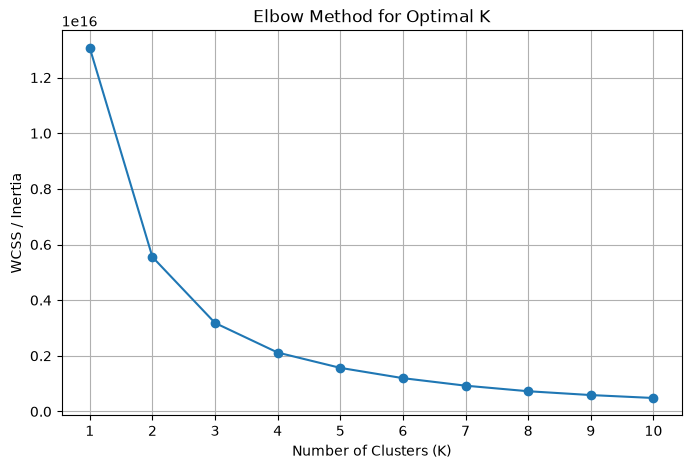

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
X = df[
    [
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        'CNT_FAM_MEMBERS'
    ]
]


km = KMeans(
n_clusters=3,
random_state=42,
n_init=10
)
km.fit(X)

df['k means cluster'] =km.labels_

print(df['k means cluster'].value_counts()) 

print("number of unique clusters:" ,np.unique(km.labels_))

print("total number of rows:" ,len(km.labels_))
print(" \n  cluster counts:")


# Elbow Method
wcss = []
for k in range(1,11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(df)
    wcss.append(km.inertia_)
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid()

plt.show()

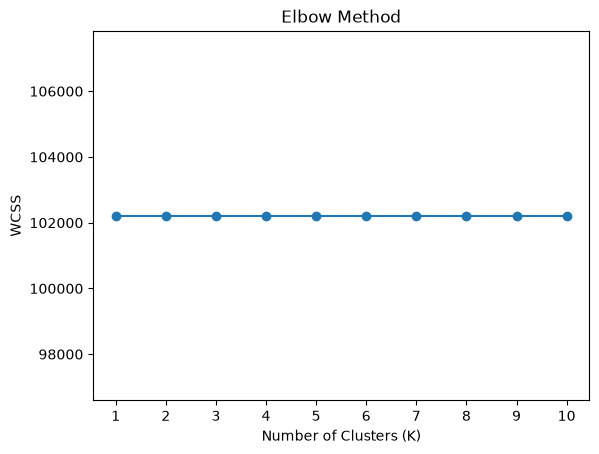

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features
X = df[
    [
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        
    ]
]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS
wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Elbow Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

In [26]:
from sklearn.cluster import KMeans

# Build K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train and predict clusters
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['KMeans_Cluster'] = kmeans_labels

# Check number of records in each cluster
print(df['KMeans_Cluster'].value_counts().sort_index())

KMeans_Cluster
0     8987
1     9915
2    29842
Name: count, dtype: int64


In [31]:
X_scaled[0:100]

array([[ 1.42475439e-01, -5.53579715e-01, -3.74772411e-02,
        -7.33476884e-01, -4.83656422e-01, -5.69579108e-02,
         1.42724091e+00, -1.64829867e-01],
       [-8.04537114e-01, -7.52831289e-01, -8.39361941e-01,
        -4.61392008e-01, -4.98481805e-01, -1.16826431e+00,
         9.10437016e-01, -1.64829867e-01],
       [ 4.01002378e-01,  2.52006551e+00,  4.97112559e-01,
        -9.17717875e-01, -4.98405600e-01,  7.86092412e-01,
        -2.87579416e-01, -1.64829867e-01],
       [ 2.89622084e+00,  1.22366563e+00,  3.30370901e+00,
         4.83623263e-01, -4.80448874e-01,  8.35352447e-01,
        -7.36835578e-01,  2.08131691e+00],
       [ 2.97650716e-01,  1.65018697e-01,  4.83747814e-01,
         6.99996623e-01, -4.82700392e-01,  2.72380613e-01,
        -7.71246689e-01,  9.58243522e-01],
       [ 1.21224888e+00,  3.23239623e-01,  1.03170236e+00,
        -5.86222792e-01, -5.50717034e-01, -3.23243589e-01,
         6.52990932e-01, -1.64829867e-01],
       [-4.79467951e-02, -4.563426

In [12]:
import pickle
with open("AgglomerativeClustering.pkl",'wb') as file:
  pickle.dump(ag_model, file)
  print ("Agglomerative model saved successfully")

Agglomerative model saved successfully


In [15]:
from sklearn.cluster import AgglomerativeClustering
ag=AgglomerativeClustering(n_clusters=3)


# Build Agglomerative model
ag_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

# Train and predict clusters
ag_labels = ag_model.fit_predict(X_scaled)
print("number of unique clusters" ,np.unique(ag.labels_))

print("total number of rows" ,len(ag.labels_))

df['Agglomerative cluster']=ag.labels_

df['Agglomerative cluster'].value_counts()



NameError: name 'X_scaled' is not defined

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)

db.fit_predict(df)

print("number of unique clusters", np.unique(db.labels_))

print("total number of rows", len(db.labels_))

df['DBSCAN cluster'] = db.labels_

df['DBSCAN cluster'].value_counts()

In [ ]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
agg_score = silhouette_score(X_scaled, agg_labels)

print("K-Means Silhouette Score:", kmeans_score)
print("Agglomerative Silhouette Score:", agg_score)